In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


In [2]:
df=load_iris()
x=df.data
y=df.target

In [3]:
scaler=StandardScaler()
x_scale=scaler.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,random_state=42,test_size=0.2)


In [6]:
model=keras.Sequential([
    keras.layers.Dense(3,activation='softmax',input_shape=(x.shape[1],))
])

D:\ANN_LABS\env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [8]:
history=model.fit(
    x_train,y_train,
    batch_size=8,
    epochs=50,
    validation_split=0.2
    
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2812 - loss: 0.9431 - val_accuracy: 0.5000 - val_loss: 0.7762
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2812 - loss: 0.9122 - val_accuracy: 0.5417 - val_loss: 0.7566
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2917 - loss: 0.8851 - val_accuracy: 0.5833 - val_loss: 0.7380
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3646 - loss: 0.8582 - val_accuracy: 0.7083 - val_loss: 0.7206
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4583 - loss: 0.8338 - val_accuracy: 0.7083 - val_loss: 0.7044
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5521 - loss: 0.8098 - val_accuracy: 0.7500 - val_loss: 0.6892
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6250 - loss: 0.7879 - val_accuracy: 0.7500 - val_loss: 0.6751
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6667 - loss: 0.7673 - val_accuracy: 0.7500 - v

In [9]:
loss,accuracy=model.evaluate(x_test,y_test)
print("accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9000 - loss: 0.3725
accuracy: 0.8999999761581421


In [10]:
y_pred=model.predict(x_test)
classes=np.argmax(y_pred,axis=1)
print("confusion matrix:",confusion_matrix(y_test,classes))
print("classification_report:",classification_report(y_test,classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
confusion matrix: [[10  0  0]
 [ 0  6  3]
 [ 0  0 11]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.67      0.80         9
           2       0.79      1.00      0.88        11

    accuracy                           0.90        30
   macro avg       0.93      0.89      0.89        30
weighted avg       0.92      0.90      0.90        30



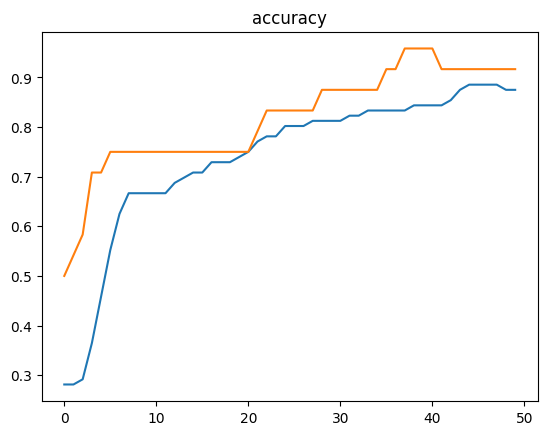

In [12]:
plt.plot(history.history['accuracy'],label="acc")
plt.plot(history.history['val_accuracy'],label="val_acc")
plt.title("accuracy")
plt.show()

In [14]:
sample=np.array([[0.2,4.1,3.3,2.1]])
scale_sample=scaler.transform(sample)
prb=model.predict(scale_sample)
print(prb)
class_index=np.argmax(prb,axis=1)
print(f"answer:{df.target_names[class_index]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
[[0.74945694 0.19109689 0.05944617]]
answer:['setosa']
